In [ ]:
# ============================================================
# Evaluation Analysis & Visualization
# ============================================================
# This notebook analyzes and visualizes the final results
# across all three models evaluated by the team:
#   1. Part 1 Simple CNN-LSTM (Andrea)
#   2. Zero-shot Qwen2.5-Omni-3B (Jamie / Andrea)
#   3. LoRA fine-tuned Qwen2.5-Omni-3B v2 (Jamie)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [2]:
# ============================================================
# Cell 1: Load and organize all results
# ============================================================
# Results are sourced from:
#   - eval_results_baseline.json (zero-shot Qwen, tested by Andrea)
#   - eval_results_lora.json (LoRA v2, tested on cluster by Jamie)
#   - Part 1 baseline results (from team baseline notebook)

results = {
    "Part 1\nCNN-LSTM": {
        "accuracy":  0.638,
        "precision": None,   # not reported in Part 1
        "recall":    None,
        "f1_score":  None,
        "mAP":       None,
        "confusion_matrix": None,
        "color": "#2196F3"
    },
    "Zero-shot\nQwen": {
        "accuracy":  0.514,
        "precision": 0.484,
        "recall":    0.930,
        "f1_score":  0.637,
        "mAP":       0.482,
        "confusion_matrix": [[44, 227], [16, 213]],
        "color": "#FF9800"
    },
    "LoRA v2\nQwen": {
        "accuracy":  0.556,
        "precision": 0.520,
        "recall":    0.941,
        "f1_score":  0.670,
        "mAP":       0.513,
        "confusion_matrix": [[53, 208], [14, 225]],
        "color": "#4CAF50"
    }
}

print("✅ Results loaded")
print(f"{'Model':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'mAP':>10}")
print("-" * 72)
for model, r in results.items():
    name = model.replace('\n', ' ')
    acc  = f"{r['accuracy']:.1%}"
    prec = f"{r['precision']:.3f}" if r['precision'] else "N/A"
    rec  = f"{r['recall']:.3f}"    if r['recall']    else "N/A"
    f1   = f"{r['f1_score']:.3f}"  if r['f1_score']  else "N/A"
    map_ = f"{r['mAP']:.3f}"       if r['mAP']       else "N/A"
    print(f"{name:<20} {acc:>10} {prec:>10} {rec:>10} {f1:>10} {map_:>10}")

✅ Results loaded
Model                  Accuracy  Precision     Recall         F1        mAP
------------------------------------------------------------------------
Part 1 CNN-LSTM           63.8%        N/A        N/A        N/A        N/A
Zero-shot Qwen            51.4%      0.484      0.930      0.637      0.482
LoRA v2 Qwen              55.6%      0.520      0.941      0.670      0.513


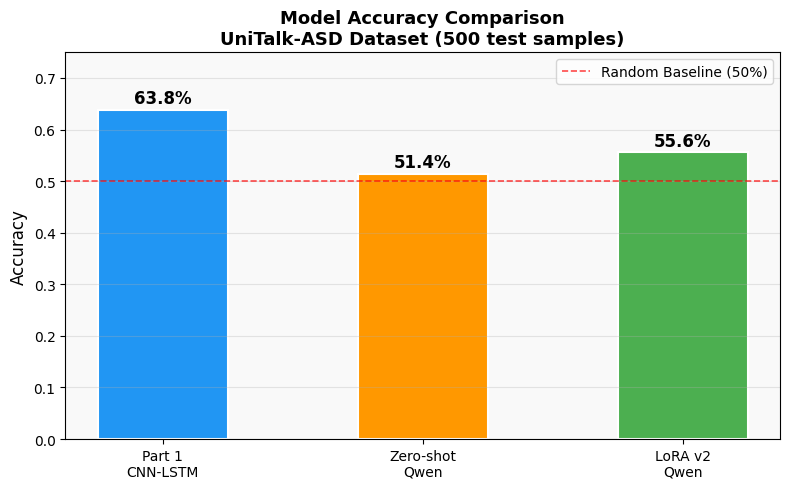

✅ Accuracy comparison saved


In [3]:
# ============================================================
# Cell 2: Accuracy Comparison Bar Chart
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

models = list(results.keys())
accuracies = [r["accuracy"] for r in results.values()]
colors = [r["color"] for r in results.values()]

bars = ax.bar(models, accuracies, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

# Annotate bars with values
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Random baseline reference line
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='Random Baseline (50%)')

ax.set_ylim(0, 0.75)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Accuracy Comparison\nUniTalk-ASD Dataset (500 test samples)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#f9f9f9')

plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Accuracy comparison saved")

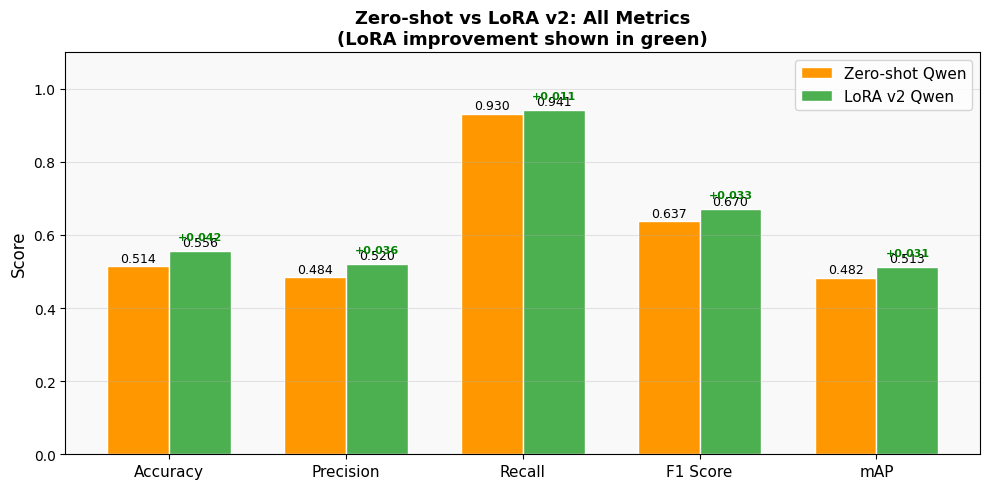

✅ Multi-metric comparison saved


In [4]:
# ============================================================
# Cell 3: Multi-Metric Comparison (Zero-shot vs LoRA)
# ============================================================
# Part 1 did not report precision/recall/F1/mAP,
# so this chart focuses on the Qwen models only.

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'mAP']

zeroshot_vals = [
    results["Zero-shot\nQwen"]["accuracy"],
    results["Zero-shot\nQwen"]["precision"],
    results["Zero-shot\nQwen"]["recall"],
    results["Zero-shot\nQwen"]["f1_score"],
    results["Zero-shot\nQwen"]["mAP"],
]

lora_vals = [
    results["LoRA v2\nQwen"]["accuracy"],
    results["LoRA v2\nQwen"]["precision"],
    results["LoRA v2\nQwen"]["recall"],
    results["LoRA v2\nQwen"]["f1_score"],
    results["LoRA v2\nQwen"]["mAP"],
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, zeroshot_vals, width, label='Zero-shot Qwen', color='#FF9800', edgecolor='white')
bars2 = ax.bar(x + width/2, lora_vals,     width, label='LoRA v2 Qwen',   color='#4CAF50', edgecolor='white')

# Annotate
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Zero-shot vs LoRA v2: All Metrics\n(LoRA improvement shown in green)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#f9f9f9')

# Highlight improvements
for i, (z, l) in enumerate(zip(zeroshot_vals, lora_vals)):
    diff = l - z
    color = 'green' if diff > 0 else 'red'
    ax.annotate(f'+{diff:.3f}' if diff > 0 else f'{diff:.3f}',
                xy=(x[i] + width/2, l + 0.03),
                ha='center', fontsize=8, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Multi-metric comparison saved")

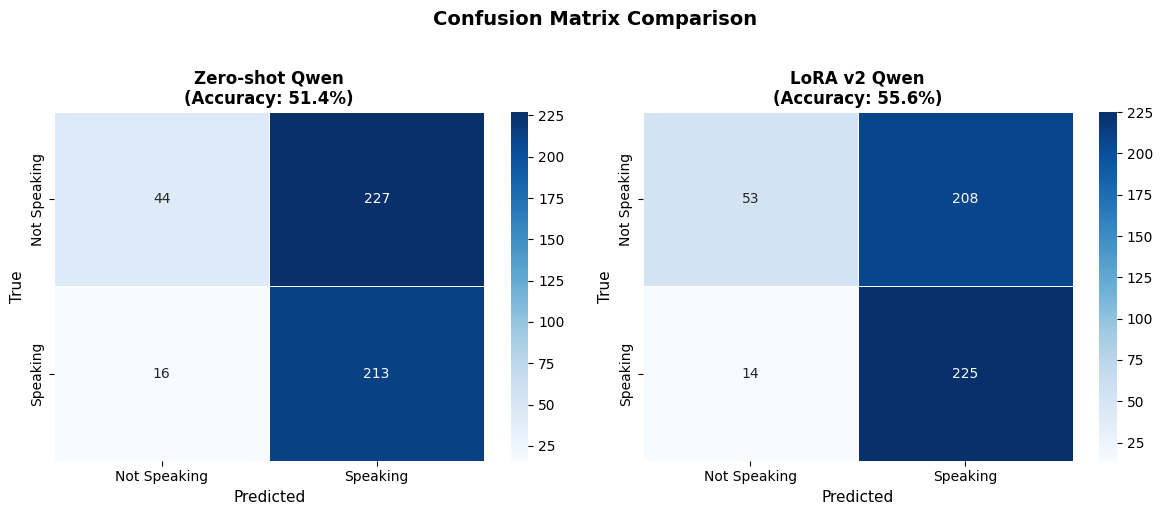

✅ Confusion matrices saved


In [5]:
# ============================================================
# Cell 4: Confusion Matrices (Zero-shot vs LoRA)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cms = {
    "Zero-shot Qwen\n(Accuracy: 51.4%)": results["Zero-shot\nQwen"]["confusion_matrix"],
    "LoRA v2 Qwen\n(Accuracy: 55.6%)":   results["LoRA v2\nQwen"]["confusion_matrix"],
}

for ax, (title, cm) in zip(axes, cms.items()):
    cm_array = np.array(cm)
    sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Speaking', 'Speaking'],
                yticklabels=['Not Speaking', 'Speaking'],
                linewidths=0.5)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrix Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved")

In [6]:
# ============================================================
# Cell 5: LoRA Improvement Analysis
# ============================================================
# Summarizes the specific improvements LoRA brought over zero-shot.

print("\n" + "="*60)
print("LORA IMPROVEMENT ANALYSIS")
print("="*60)

metrics_list = ['accuracy', 'precision', 'recall', 'f1_score', 'mAP']
labels       = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'mAP']

for metric, label in zip(metrics_list, labels):
    z = results["Zero-shot\nQwen"][metric]
    l = results["LoRA v2\nQwen"][metric]
    diff = l - z
    pct = diff / z * 100
    sign = "+" if diff > 0 else ""
    print(f"{label:<12}: {z:.3f} → {l:.3f}  ({sign}{diff:.3f}, {sign}{pct:.1f}%)")

print("\nConfusion Matrix Analysis:")
zs_cm = np.array(results["Zero-shot\nQwen"]["confusion_matrix"])
lr_cm = np.array(results["LoRA v2\nQwen"]["confusion_matrix"])

print(f"  Not Speaking correctly identified: {zs_cm[0,0]} → {lr_cm[0,0]} (+{lr_cm[0,0]-zs_cm[0,0]})")
print(f"  Speaking correctly identified:     {zs_cm[1,1]} → {lr_cm[1,1]} (+{lr_cm[1,1]-zs_cm[1,1]})")
print(f"  False positives (Not→Speaking):    {zs_cm[0,1]} → {lr_cm[0,1]} ({lr_cm[0,1]-zs_cm[0,1]:+d})")
print(f"  False negatives (Speaking→Not):    {zs_cm[1,0]} → {lr_cm[1,0]} ({lr_cm[1,0]-zs_cm[1,0]:+d})")

print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"Part 1 CNN-LSTM:    63.8%  (task-specific, best overall)")
print(f"Zero-shot Qwen:     51.4%  (foundation model, no fine-tuning)")
print(f"LoRA v2 Qwen:       55.6%  (+4.2% over zero-shot)")
print(f"\nKey finding: Task-specific architecture outperforms LLM-based")
print(f"approach, but LoRA fine-tuning shows meaningful improvement")
print(f"over zero-shot, demonstrating the value of domain adaptation.")
print("="*60)


LORA IMPROVEMENT ANALYSIS
Accuracy    : 0.514 → 0.556  (+0.042, +8.2%)
Precision   : 0.484 → 0.520  (+0.036, +7.4%)
Recall      : 0.930 → 0.941  (+0.011, +1.2%)
F1 Score    : 0.637 → 0.670  (+0.033, +5.2%)
mAP         : 0.482 → 0.513  (+0.031, +6.4%)

Confusion Matrix Analysis:
  Not Speaking correctly identified: 44 → 53 (+9)
  Speaking correctly identified:     213 → 225 (+12)
  False positives (Not→Speaking):    227 → 208 (-19)
  False negatives (Speaking→Not):    16 → 14 (-2)

FINAL SUMMARY
Part 1 CNN-LSTM:    63.8%  (task-specific, best overall)
Zero-shot Qwen:     51.4%  (foundation model, no fine-tuning)
LoRA v2 Qwen:       55.6%  (+4.2% over zero-shot)

Key finding: Task-specific architecture outperforms LLM-based
approach, but LoRA fine-tuning shows meaningful improvement
over zero-shot, demonstrating the value of domain adaptation.
